In [1]:
from torchvision import datasets
import torch
data_folder = '~/data/FMNIST' # This can be any directory you want
# to download FMNIST to
fmnist = datasets.FashionMNIST(data_folder, download=True, train=True)


100%|██████████| 26.4M/26.4M [00:01<00:00, 18.6MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 301kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.54MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 20.2MB/s]


In [2]:
tr_images = fmnist.data
tr_targets = fmnist.targets

In [3]:
unique_values = tr_targets.unique()
print(f'tr_images & tr_targets: \n\tX - {tr_images.shape}\n\tY - {tr_targets.shape}\n\tY Unique Values: {unique_values}')
print(f'TASK:\n\t{len(unique_values)} class Classification')
print(f'UNIQUE CLASSES:\n\t{fmnist.classes}')

tr_images & tr_targets: 
	X - torch.Size([60000, 28, 28])
	Y - torch.Size([60000])
	Y Unique Values: tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
TASK:
	10 class Classification
UNIQUE CLASSES:
	['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


In [4]:

import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np

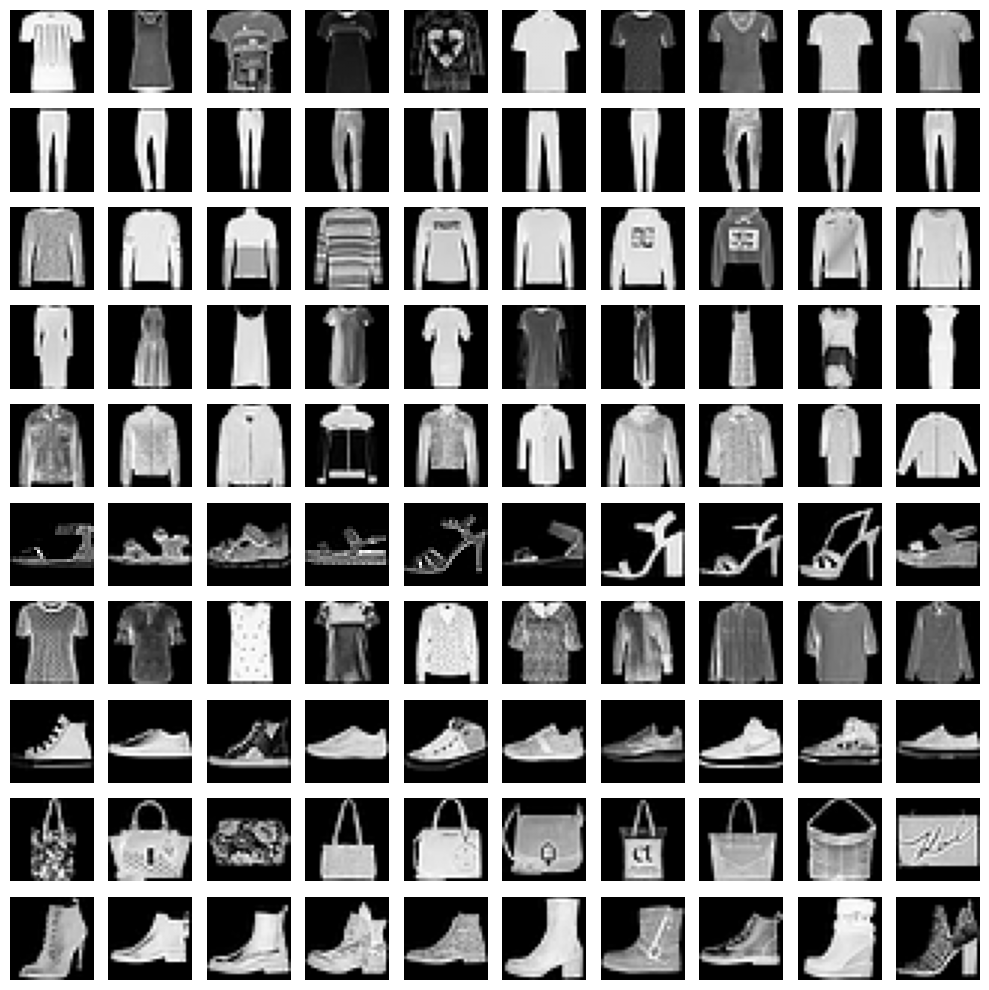

In [5]:
R, C = len(tr_targets.unique()), 10
fig, ax = plt.subplots(R, C, figsize=(10,10))
for label_class, plot_row in enumerate(ax):
    label_x_rows = np.where(tr_targets == label_class)[0]
    for plot_cell in plot_row:
        plot_cell.grid(False); plot_cell.axis('off')
        ix = np.random.choice(label_x_rows)
        x, y = tr_images[ix], tr_targets[ix]
        plot_cell.imshow(x, cmap='gray')
plt.tight_layout()

In [6]:
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
device = "cuda" if torch.cuda.is_available() else "cpu"
from torchvision import datasets
data_folder = '~/data/FMNIST' # This can be any directory you want to
# download FMNIST to
fmnist = datasets.FashionMNIST(data_folder, download=True, train=True)
tr_images = fmnist.data
tr_targets = fmnist.targets

In [8]:
class FMNISTDataset(Dataset):
    def __init__(self, x, y):
        x = x.float()
        x = x.view(-1,28*28)
        self.x, self.y = x, y
    def __getitem__(self, ix):
        x, y = self.x[ix], self.y[ix]
        return x.to(device), y.to(device)
    def __len__(self):
        return len(self.x)

In [9]:
def get_data():
    train = FMNISTDataset(tr_images, tr_targets)
    trn_dl = DataLoader(train, batch_size=32, shuffle=True)
    return trn_dl

In [10]:
from torch.optim import SGD
def get_model():
    model = nn.Sequential(
        nn.Linear(28 * 28, 1000),
        nn.ReLU(),
        nn.Linear(1000, 10)
          ).to(device)
    loss_fn = nn.CrossEntropyLoss()
    optimizer = SGD(model.parameters(), lr=1e-2)
    return model, loss_fn, optimizer
tr_images = fmnist.data
tr_targets = fmnist.targets

In [13]:
def train_batch(x, y, model, opt, loss_fn):
    model.train()
    prediction = model(x)
    batch_loss = loss_fn(prediction, y)
    batch_loss.backward()
    opt.step()         # Sửa lỗi gọi trùng tên biến optimizer cục bộ
    opt.zero_grad()
    return batch_loss.item()

In [14]:
@torch.no_grad()
def accuracy(x, y, model):
    model.eval()
    prediction = model(x)
    max_values, argmaxes = prediction.max(-1)
    is_correct = argmaxes == y
    return is_correct.cpu().numpy().tolist()

In [15]:
trn_dl = get_data()
model, loss_fn, optimizer = get_model()
losses, accuracies = [], []

for epoch in range(5):
    print(f"Epoch đang chạy: {epoch}")
    train_epoch_losses, train_epoch_accuracies = [], []

    for ix, batch in enumerate(iter(trn_dl)):
        x, y = batch
        x, y = x.to(device), y.to(device)
        batch_loss = train_batch(x, y, model, optimizer, loss_fn)
        train_epoch_losses.append(batch_loss)
    train_epoch_loss = np.array(train_epoch_losses).mean()

    for ix, batch in enumerate(iter(trn_dl)):
        x, y = batch
        x, y = x.to(device), y.to(device)
        is_correct = accuracy(x, y, model)
        train_epoch_accuracies.extend(is_correct)
    train_epoch_accuracy = np.mean(train_epoch_accuracies)

    losses.append(train_epoch_loss)
    accuracies.append(train_epoch_accuracy)

Epoch đang chạy: 0
Epoch đang chạy: 1
Epoch đang chạy: 2
Epoch đang chạy: 3
Epoch đang chạy: 4


/tmp/ipykernel_9031/180550757.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(['{:.0f}%'.format(x*100) for x in plt.gca().get_yticks()])


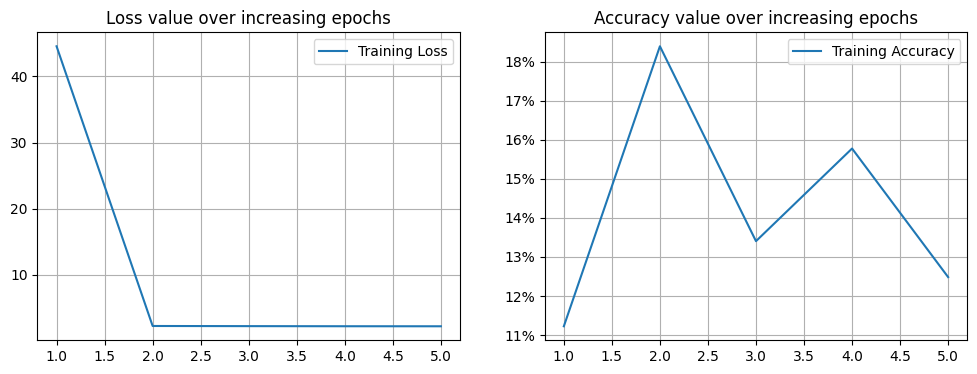

In [16]:
epochs = np.arange(5) + 1

plt.figure(figsize=(12, 4))
plt.subplot(121)
plt.title('Loss value over increasing epochs')
plt.plot(epochs, losses, label='Training Loss')
plt.legend(); plt.grid(True)

plt.subplot(122)
plt.title('Accuracy value over increasing epochs')
plt.plot(epochs, accuracies, label='Training Accuracy')
plt.gca().set_yticklabels(['{:.0f}%'.format(x*100) for x in plt.gca().get_yticks()])
plt.legend(); plt.grid(True)
plt.show()

In [19]:
from torchvision import datasets
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
device = "cuda" if torch.cuda.is_available() else "cpu"
import numpy as np
data_folder = '~/data/FMNIST' # This can be any directory you want
# to download FMNIST to
fmnist = datasets.FashionMNIST(data_folder, download=True, train=True)
tr_images = fmnist.data
tr_targets = fmnist.targets

In [20]:
class FMNISTDataset(Dataset):
    def __init__(self, x, y):
        x = x.float()/255
        x = x.view(-1,28*28)
        self.x, self.y = x, y
    def __getitem__(self, ix):
        x, y = self.x[ix], self.y[ix]
        return x.to(device), y.to(device)
    def __len__(self):
        return len(self.x)

In [22]:
def get_data():
    train = FMNISTDataset(tr_images, tr_targets)
    trn_dl = DataLoader(train, batch_size=32, shuffle=True)
    return trn_dl
from torch.optim import SGD
def get_model():
    model = nn.Sequential(
        nn.Linear(28 * 28, 1000),
        nn.ReLU(),
        nn.Linear(1000, 10)
    ).to(device)
    loss_fn = nn.CrossEntropyLoss()
    optimizer = SGD(model.parameters(), lr=1e-2)
    return model, loss_fn, optimizer
def train_batch(x, y, model, opt, loss_fn):
    model.train()
    # call your model like any python function on your batch of inputs
    prediction = model(x)
    # compute loss
    batch_loss = loss_fn(prediction, y)
    # based on the forward pass in `model(x)` compute all the gradients of
    # 'model.parameters()'
    batch_loss.backward()
    # apply new-weights = f(old-weights, old-weight-gradients)
    # where "f" is the optimizer
    optimizer.step()
    # Flush memory for next batch of calculations
    optimizer.zero_grad()
    return batch_loss.item()
def accuracy(x, y, model):
    model.eval()
    # since there's no need for updating weights, we might
    # as well not compute the gradients
    with torch.no_grad():
        # get the prediction matrix for a tensor of `x` images
        prediction = model(x)
    # compute if the location of maximum in each row coincides
    # with ground truth
    max_values, argmaxes = prediction.max(-1)
    is_correct = argmaxes == y
    return is_correct.cpu().numpy().tolist()
trn_dl = get_data()
model, loss_fn, optimizer = get_model()
losses, accuracies = [], []
for epoch in range(5):
    print(epoch)
    epoch_losses, epoch_accuracies = [], []
    for ix, batch in enumerate(iter(trn_dl)):
        x, y = batch
        batch_loss = train_batch(x, y, model, optimizer, loss_fn)
        epoch_losses.append(batch_loss)
    epoch_loss = np.array(epoch_losses).mean()
    for ix, batch in enumerate(iter(trn_dl)):
        x, y = batch
        is_correct = accuracy(x, y, model)
        epoch_accuracies.extend(is_correct)
    epoch_accuracy = np.mean(epoch_accuracies)
    losses.append(epoch_loss)
    accuracies.append(epoch_accuracy)

0
1
2
3
4


/tmp/ipykernel_9031/3801828047.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(['{:.0f}%'.format(x*100) for x in


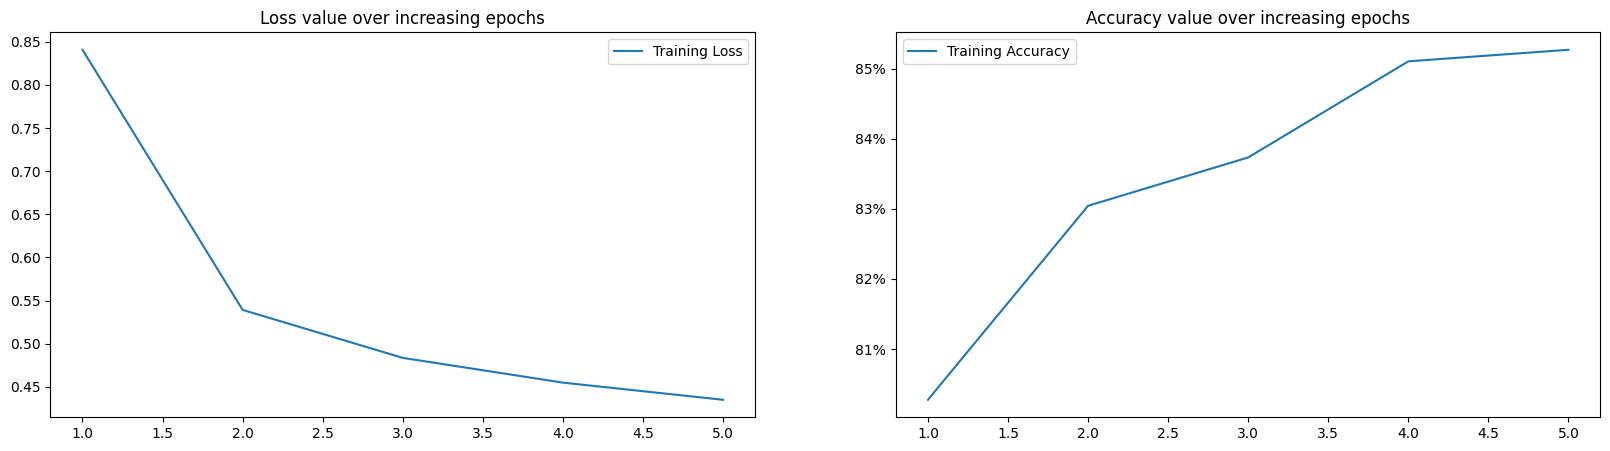

In [25]:
epochs = np.arange(5)+1
import matplotlib.pyplot as plt
%matplotlib inline
plt.figure(figsize=(20,5))
plt.subplot(121)
plt.title('Loss value over increasing epochs')
plt.plot(epochs, losses, label='Training Loss')
plt.legend()
plt.subplot(122)
plt.title('Accuracy value over increasing epochs')
plt.plot(epochs, accuracies, label='Training Accuracy')
plt.gca().set_yticklabels(['{:.0f}%'.format(x*100) for x in
plt.gca().get_yticks()])
plt.legend()


In [26]:
from torchvision import datasets
import torch
data_folder = '~/data/FMNIST' # This can be any directory you want to
# download FMNIST to
fmnist = datasets.FashionMNIST(data_folder, download=True, train=True)
tr_images = fmnist.data
tr_targets = fmnist.targets

/tmp/ipykernel_9031/4178376221.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(['{:.0f}%'.format(x*100) for x in


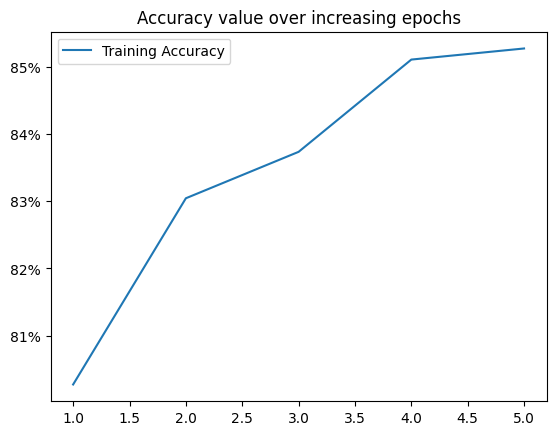

In [27]:
val_fmnist = datasets.FashionMNIST(data_folder, download=True, train=False)
val_images = val_fmnist.data
val_targets = val_fmnist.targets
plt.title('Accuracy value over increasing epochs')
plt.plot(epochs, accuracies, label='Training Accuracy')
plt.gca().set_yticklabels(['{:.0f}%'.format(x*100) for x in
plt.gca().get_yticks()])
plt.legend()

In [28]:
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
from torch.utils.data import Dataset, DataLoader

In [29]:
import torch
import torch.nn as nn
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [32]:
class FMNISTDataset(Dataset):
    def __init__(self, x, y):
        x = x.float()/255
        x = x.view(-1,28*28)
        self.x, self.y = x, y
    def __getitem__(self, ix):
        x, y = self.x[ix], self.y[ix]
        return x.to(device), y.to(device)
    def __len__(self):
        return len(self.x)

from torch.optim import SGD, Adam
def get_model():
    model = nn.Sequential(
        nn.Linear(28 * 28, 1000),
        nn.ReLU(),
        nn.Linear(1000, 10)
    ).to(device)

    loss_fn = nn.CrossEntropyLoss()
    optimizer = Adam(model.parameters(), lr=1e-2)
    return model, loss_fn, optimizer

def train_batch(x, y, model, opt, loss_fn):
    model.train()
    prediction = model(x)
    batch_loss = loss_fn(prediction, y)
    batch_loss.backward()
    optimizer.step()
    optimizer.zero_grad()
    return batch_loss.item()

def accuracy(x, y, model):
    model.eval()
    # this is the same as @torch.no_grad
     # at the top of function, only difference
    # being, grad is not computed in the with scope
    with torch.no_grad():
        prediction = model(x)
    max_values, argmaxes = prediction.max(-1)
    is_correct = argmaxes == y
    return is_correct.cpu().numpy().tolist()

In [33]:

def get_data():
    train = FMNISTDataset(tr_images, tr_targets)
    trn_dl = DataLoader(train, batch_size=32, shuffle=True)
    val = FMNISTDataset(val_images, val_targets)
    val_dl = DataLoader(val, batch_size=len(val_images), shuffle=False)
    return trn_dl, val_dl


In [34]:
torch.no_grad()
def val_loss(x, y, model):
    prediction = model(x)
    val_loss = loss_fn(prediction, y)
    return val_loss.item()

In [35]:
trn_dl, val_dl = get_data()
model, loss_fn, optimizer = get_model()

In [40]:
train_losses, train_accuracies = [], []
val_losses, val_accuracies = [], []
for epoch in range(5):
    print(epoch)
    train_epoch_losses, train_epoch_accuracies = [], []
    for ix, batch in enumerate(iter(trn_dl)):
        x, y = batch
        batch_loss = train_batch(x, y, model, optimizer, loss_fn)
        train_epoch_losses.append(batch_loss)
    train_epoch_loss = np.array(train_epoch_losses).mean()
    for ix, batch in enumerate(iter(trn_dl)):
        x, y = batch
        is_correct = accuracy(x, y, model)
        train_epoch_accuracies.extend(is_correct)
    train_epoch_accuracy = np.mean(train_epoch_accuracies)
    for ix, batch in enumerate(iter(val_dl)):
        x, y = batch
        val_is_correct = accuracy(x, y, model)
        validation_loss = val_loss(x, y, model)
    val_epoch_accuracy = np.mean(val_is_correct)
    train_losses.append(train_epoch_loss)
    train_accuracies.append(train_epoch_accuracy)
    val_losses.append(validation_loss)
    val_accuracies.append(val_epoch_accuracy)


0
1
2
3
4


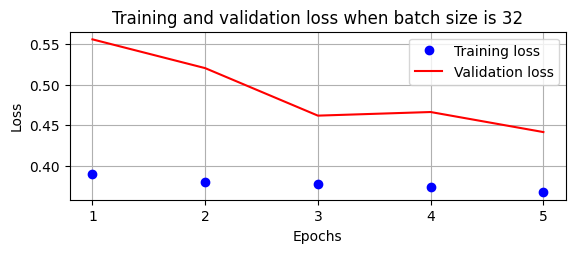

/tmp/ipykernel_9031/4245033372.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(['{:.0f}%'.format(x*100) for x in


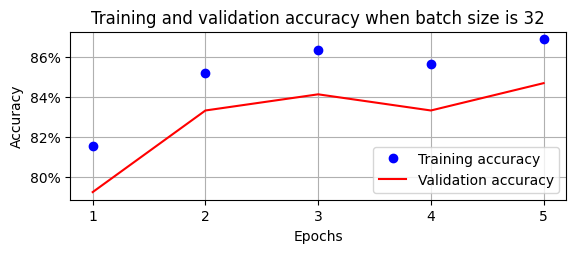

In [41]:
epochs = np.arange(5)+1
import matplotlib.ticker as mtick
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
%matplotlib inline
plt.subplot(211)
plt.plot(epochs, train_losses, 'bo', label='Training loss')
plt.plot(epochs, val_losses, 'r', label='Validation loss')
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.title('Training and validation loss when batch size is 32')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid('off')
plt.show()
plt.subplot(212)
plt.plot(epochs, train_accuracies, 'bo', label='Training accuracy')
plt.plot(epochs, val_accuracies, 'r', label='Validation accuracy')
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.title('Training and validation accuracy when batch size is 32')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.gca().set_yticklabels(['{:.0f}%'.format(x*100) for x in
plt.gca().get_yticks()])
plt.legend()
plt.grid('off')



plt.show()


0
1
2
3
4


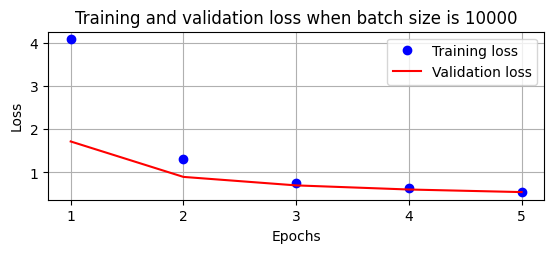

/tmp/ipykernel_9031/3824235148.py:56: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(['{:.0f}%'.format(x*100) for x in


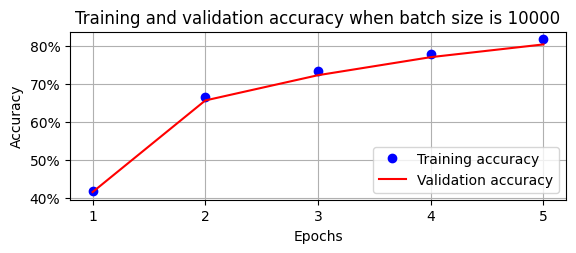

In [43]:
def get_data():
    train = FMNISTDataset(tr_images, tr_targets)
    trn_dl = DataLoader(train, batch_size=10000, shuffle=True)
    val = FMNISTDataset(val_images, val_targets)
    val_dl = DataLoader(val, batch_size=len(val_images), shuffle=False)
    return trn_dl, val_dl
trn_dl, val_dl = get_data()
model, loss_fn, optimizer = get_model()
train_losses, train_accuracies = [], []
val_losses, val_accuracies = [], []
for epoch in range(5):
    print(epoch)
    train_epoch_losses, train_epoch_accuracies = [], []
    for ix, batch in enumerate(iter(trn_dl)):
        x, y = batch
        batch_loss = train_batch(x, y, model, optimizer, loss_fn)
        train_epoch_losses.append(batch_loss)
    train_epoch_loss = np.array(train_epoch_losses).mean()

    for ix, batch in enumerate(iter(trn_dl)):
        x, y = batch
        is_correct = accuracy(x, y, model)
        train_epoch_accuracies.extend(is_correct)
    train_epoch_accuracy = np.mean(train_epoch_accuracies)
    for ix, batch in enumerate(iter(val_dl)):
        x, y = batch
        val_is_correct = accuracy(x, y, model)
        validation_loss = val_loss(x, y, model)
    val_epoch_accuracy = np.mean(val_is_correct)
    train_losses.append(train_epoch_loss)
    train_accuracies.append(train_epoch_accuracy)
    val_losses.append(validation_loss)
    val_accuracies.append(val_epoch_accuracy)
epochs = np.arange(5)+1
import matplotlib.ticker as mtick
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
%matplotlib inline
plt.subplot(211)
plt.plot(epochs, train_losses, 'bo', label='Training loss')
plt.plot(epochs, val_losses, 'r', label='Validation loss')
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.title('Training and validation loss when batch size is 10000')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid('off')
plt.show()
plt.subplot(212)
plt.plot(epochs, train_accuracies, 'bo', label='Training accuracy')
plt.plot(epochs, val_accuracies, 'r', label='Validation accuracy')
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.title('Training and validation accuracy when batch size is 10000')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.gca().set_yticklabels(['{:.0f}%'.format(x*100) for x in
plt.gca().get_yticks()])
plt.legend()
plt.grid('off')
plt.show()


100%|██████████| 26.4M/26.4M [00:01<00:00, 19.5MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 301kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.53MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 10.6MB/s]


Epoch 0 -> Train Acc: 80.93% | Val Acc: 79.47%
Epoch 1 -> Train Acc: 83.51% | Val Acc: 82.31%
Epoch 2 -> Train Acc: 84.36% | Val Acc: 83.00%
Epoch 3 -> Train Acc: 84.66% | Val Acc: 83.29%
Epoch 4 -> Train Acc: 85.32% | Val Acc: 83.70%
Epoch 5 -> Train Acc: 86.16% | Val Acc: 84.55%
Epoch 6 -> Train Acc: 86.48% | Val Acc: 84.83%
Epoch 7 -> Train Acc: 86.76% | Val Acc: 85.17%
Epoch 8 -> Train Acc: 86.78% | Val Acc: 84.86%
Epoch 9 -> Train Acc: 87.43% | Val Acc: 85.72%


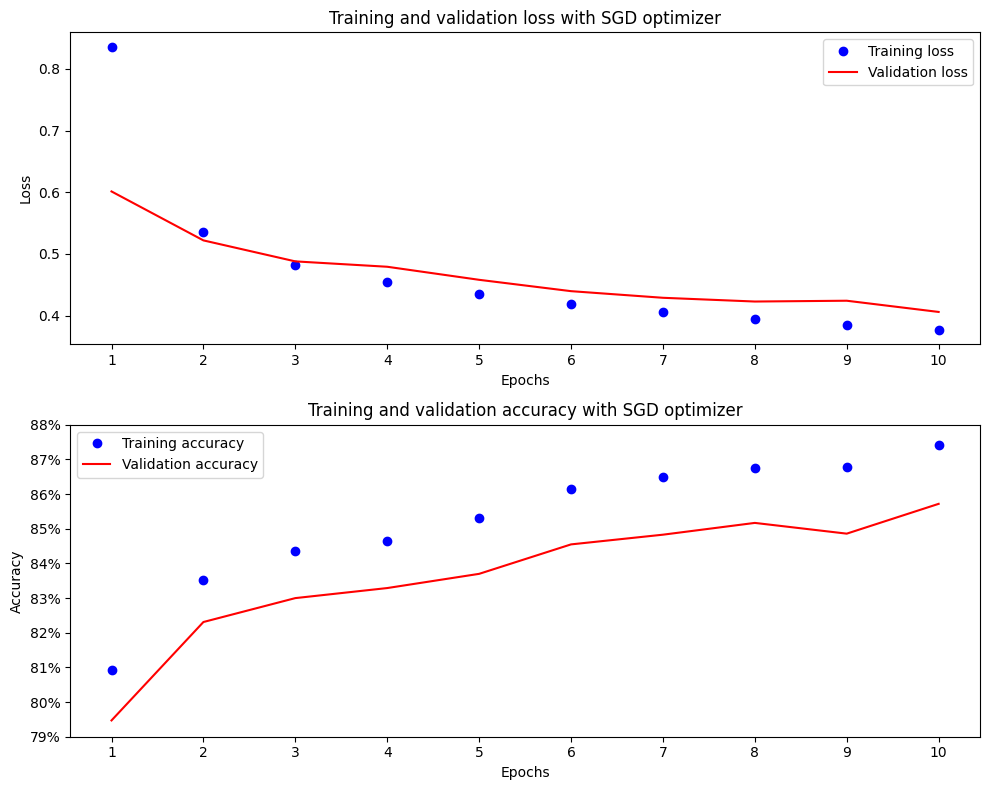

In [44]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import SGD
from torchvision import datasets
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Bật chế độ vẽ đồ thị hiển thị trực quan ngay dưới ô code
%matplotlib inline

device = 'cuda' if torch.cuda.is_available() else 'cpu'
data_folder = './data/FMNIST'

# --- TẢI DỮ LIỆU ĐẦU VÀO ---
fmnist = datasets.FashionMNIST(data_folder, download=True, train=True)
tr_images = fmnist.data
tr_targets = fmnist.targets

val_fmnist = datasets.FashionMNIST(data_folder, download=True, train=False)
val_images = val_fmnist.data
val_targets = val_fmnist.targets

# --- LỚP DATASET VÀ QUẢN LÝ DỮ LIỆU ---
class FMNISTDataset(Dataset):
    def __init__(self, x, y):
        x = x.float() / 255
        x = x.view(-1, 28*28)
        self.x, self.y = x, y
    def __getitem__(self, ix):
        return self.x[ix].to(device), self.y[ix].to(device)
    def __len__(self):
        return len(self.x)

def get_data():
    train = FMNISTDataset(tr_images, tr_targets)
    trn_dl = DataLoader(train, batch_size=32, shuffle=True)
    val = FMNISTDataset(val_images, val_targets)
    val_dl = DataLoader(val, batch_size=len(val_images), shuffle=False)
    return trn_dl, val_dl

# --- KHỞI TẠO MÔ HÌNH MẠNG NƠ-RON ---
def get_model():
    model = nn.Sequential(
        nn.Linear(28 * 28, 1000),
        nn.ReLU(),
        nn.Linear(1000, 10)
    ).to(device)

    loss_fn = nn.CrossEntropyLoss()
    optimizer = SGD(model.parameters(), lr=1e-2)
    return model, loss_fn, optimizer

# SỬA LỖI 1: Thay 'optimizer' bằng 'opt' để đồng bộ tham số truyền vào hàm
def train_batch(x, y, model, opt, loss_fn):
    model.train()
    prediction = model(x)
    batch_loss = loss_fn(prediction, y)
    batch_loss.backward()
    opt.step()
    opt.zero_grad()
    return batch_loss.item()

# SỬA LỖI 2: Đã sửa lại căn lề chuẩn (Indentation) cho khối lệnh no_grad
def accuracy(x, y, model):
    model.eval()
    with torch.no_grad():
        prediction = model(x)
    max_values, argmaxes = prediction.max(-1)
    is_correct = argmaxes == y
    return is_correct.cpu().numpy().tolist()

@torch.no_grad()
def val_loss(x, y, model, loss_fn):
    model.eval()
    prediction = model(x)
    val_loss_val = loss_fn(prediction, y)
    return val_loss_val.item()

# --- TIẾN HÀNH CHẠY HUẤN LUYỆN (10 EPOCHS) ---
trn_dl, val_dl = get_data()
model, loss_fn, optimizer = get_model()

train_losses, train_accuracies = [], []
val_losses, val_accuracies = [], []

for epoch in range(10):
    train_epoch_losses, train_epoch_accuracies = [], []

    for ix, batch in enumerate(iter(trn_dl)):
        x, y = batch
        batch_loss = train_batch(x, y, model, optimizer, loss_fn)
        train_epoch_losses.append(batch_loss)
    train_epoch_loss = np.array(train_epoch_losses).mean()

    for ix, batch in enumerate(iter(trn_dl)):
        x, y = batch
        is_correct = accuracy(x, y, model)
        train_epoch_accuracies.extend(is_correct)
    train_epoch_accuracy = np.mean(train_epoch_accuracies)

    for ix, batch in enumerate(iter(val_dl)):
        x, y = batch
        val_is_correct = accuracy(x, y, model)
        validation_loss = val_loss(x, y, model, loss_fn)
        val_epoch_accuracy = np.mean(val_is_correct)

    train_losses.append(train_epoch_loss)
    train_accuracies.append(train_epoch_accuracy)
    val_losses.append(validation_loss)
    val_accuracies.append(val_epoch_accuracy)
    print(f"Epoch {epoch} -> Train Acc: {train_epoch_accuracy*100:.2f}% | Val Acc: {val_epoch_accuracy*100:.2f}%")

# --- PHẦN V VẼ BIỂU ĐỒ KÉP HÀNG DỌC (Trang 32) ---
epochs = np.arange(10) + 1
plt.figure(figsize=(10, 8)) # Khởi tạo khung hình chung rộng rãi

# Biểu đồ 1: Loss
plt.subplot(211)
plt.plot(epochs, train_losses, 'bo', label='Training loss')
plt.plot(epochs, val_losses, 'r', label='Validation loss')
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.title('Training and validation loss with SGD optimizer')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(False)

# Biểu đồ 2: Accuracy
plt.subplot(212)
plt.plot(epochs, train_accuracies, 'bo', label='Training accuracy')
plt.plot(epochs, val_accuracies, 'r', label='Validation accuracy')
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.title('Training and validation accuracy with SGD optimizer')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

# Chuẩn hóa định dạng nhãn phần trăm trục Y
ticks_loc = plt.gca().get_yticks()
plt.gca().set_yticks(ticks_loc)
plt.gca().set_yticklabels(['{:.0f}%'.format(x*100) for x in ticks_loc])

plt.legend()
plt.grid(False)

plt.tight_layout() # Tự động giãn khoảng cách chống đè chữ giữa 2 bảng đồ thị
plt.show()         # SỬA LỖI 3: Chỉ gọi duy nhất 1 lần ở cuối cùng

Epoch 0 (Adam) -> Train Acc: 83.75% | Val Acc: 81.99%
Epoch 1 (Adam) -> Train Acc: 84.22% | Val Acc: 83.49%
Epoch 2 (Adam) -> Train Acc: 84.77% | Val Acc: 83.01%
Epoch 3 (Adam) -> Train Acc: 85.66% | Val Acc: 83.88%
Epoch 4 (Adam) -> Train Acc: 85.83% | Val Acc: 84.20%
Epoch 5 (Adam) -> Train Acc: 86.65% | Val Acc: 84.51%
Epoch 6 (Adam) -> Train Acc: 87.14% | Val Acc: 85.38%
Epoch 7 (Adam) -> Train Acc: 86.17% | Val Acc: 83.92%
Epoch 8 (Adam) -> Train Acc: 87.78% | Val Acc: 85.61%
Epoch 9 (Adam) -> Train Acc: 87.12% | Val Acc: 84.50%


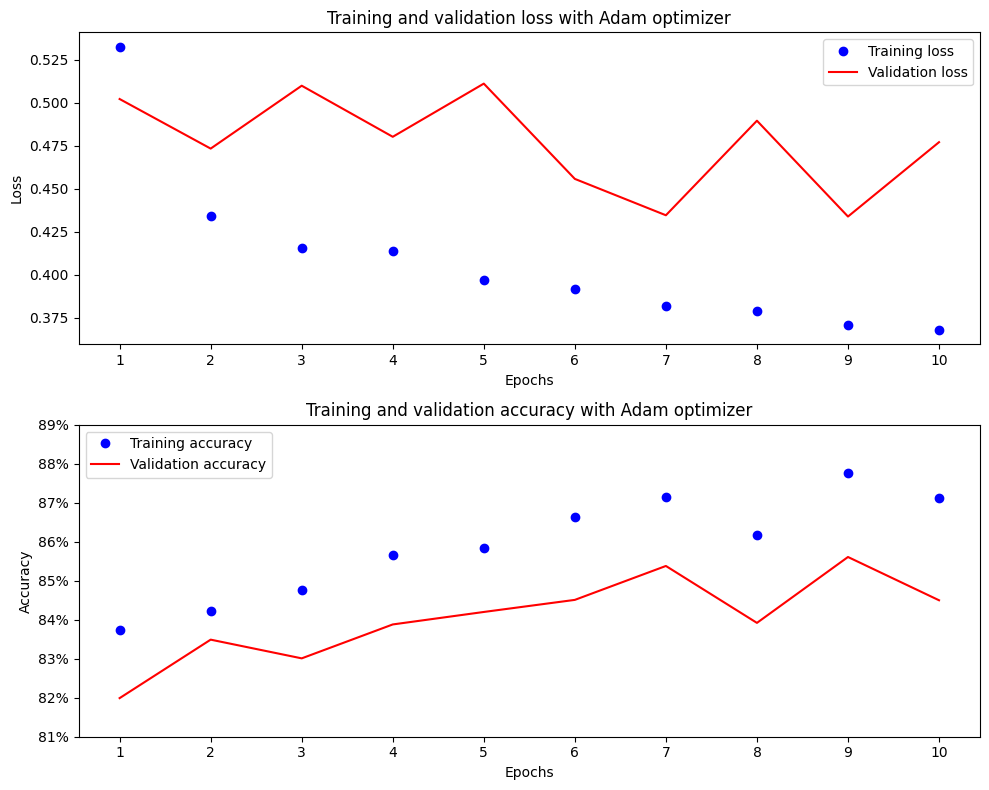

In [46]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from torch.optim import Adam

# Gọi dữ liệu và mô hình mới
trn_dl, val_dl = get_data()

# Khởi tạo mô hình định nghĩa bộ tối ưu hóa Adam (Trang 30 - 31)
def get_model_adam():
    model = nn.Sequential(
        nn.Linear(28 * 28, 1000),
        nn.ReLU(),
        nn.Linear(1000, 10)
    ).to(device)

    loss_fn = nn.CrossEntropyLoss()
    # Đổi sang bộ tối ưu Adam với cấu hình lr=1e-2 theo tài liệu
    optimizer = Adam(model.parameters(), lr=1e-2)
    return model, loss_fn, optimizer

model, loss_fn, optimizer = get_model_adam()

train_losses, train_accuracies = [], []
val_losses, val_accuracies = [], []

for epoch in range(10):
    train_epoch_losses, train_epoch_accuracies = [], []

    # 1. Chu trình huấn luyện (Lan truyền ngược cập nhật trọng số)
    for ix, batch in enumerate(iter(trn_dl)):
        x, y = batch
        batch_loss = train_batch(x, y, model, optimizer, loss_fn)
        train_epoch_losses.append(batch_loss)
    train_epoch_loss = np.array(train_epoch_losses).mean()

    # 2. Chu trình đo độ chính xác tập huấn luyện (Train)
    for ix, batch in enumerate(iter(trn_dl)):
        x, y = batch
        is_correct = accuracy(x, y, model)
        train_epoch_accuracies.extend(is_correct)
    # ĐÃ SỬA: Đưa dòng này ra ngoài vòng lặp for để tính chính xác trung bình toàn bộ Epoch
    train_epoch_accuracy = np.mean(train_epoch_accuracies)

    # 3. Chu trình đo lường tập kiểm thử (Validation)
    for ix, batch in enumerate(iter(val_dl)):
        x, y = batch
        val_is_correct = accuracy(x, y, model)
        # ĐÃ SỬA: Truyền thêm loss_fn để tránh lỗi thiếu đối số positional argument
        validation_loss = val_loss(x, y, model, loss_fn)
    val_epoch_accuracy = np.mean(val_is_correct)

    train_losses.append(train_epoch_loss)
    train_accuracies.append(train_epoch_accuracy)
    val_losses.append(validation_loss)
    val_accuracies.append(val_epoch_accuracy)

    print(f"Epoch {epoch} (Adam) -> Train Acc: {train_epoch_accuracy*100:.2f}% | Val Acc: {val_epoch_accuracy*100:.2f}%")

# --- PHẦN VẼ ĐỒ THỊ KÉP HÀNG DỌC CHO BỘ TỐI ƯU ADAM (Trang 32) ---
epochs = np.arange(10) + 1
plt.figure(figsize=(10, 8)) # Khởi tạo khung biểu đồ chung

# Subplot 211: Đồ thị Loss
plt.subplot(211)
plt.plot(epochs, train_losses, 'bo', label='Training loss')
plt.plot(epochs, val_losses, 'r', label='Validation loss')
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.title('Training and validation loss with Adam optimizer')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(False)

# Subplot 212: Đồ thị Accuracy
plt.subplot(212)
plt.plot(epochs, train_accuracies, 'bo', label='Training accuracy')
plt.plot(epochs, val_accuracies, 'r', label='Validation accuracy')
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.title('Training and validation accuracy with Adam optimizer')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

# Chuẩn hóa nhãn phần trăm (%) hiển thị tốt trên mọi môi trường
ticks_loc = plt.gca().get_yticks()
plt.gca().set_yticks(ticks_loc)
plt.gca().set_yticklabels(['{:.0f}%'.format(x*100) for x in ticks_loc])

plt.legend()
plt.grid(False)

plt.tight_layout() # Giãn khoảng cách giữa 2 đồ thị tránh đè chữ lên nhau
plt.show()         # SỬA LỖI: Chỉ gọi duy nhất 1 lần ở cuối cùng

Epoch 0 -> Train Loss: 2.4979 | Train Acc: 43.86%
Epoch 1 -> Train Loss: 1.5934 | Train Acc: 28.48%
Epoch 2 -> Train Loss: 1.7959 | Train Acc: 26.55%
Epoch 3 -> Train Loss: 1.7433 | Train Acc: 28.82%
Epoch 4 -> Train Loss: 1.7628 | Train Acc: 29.88%


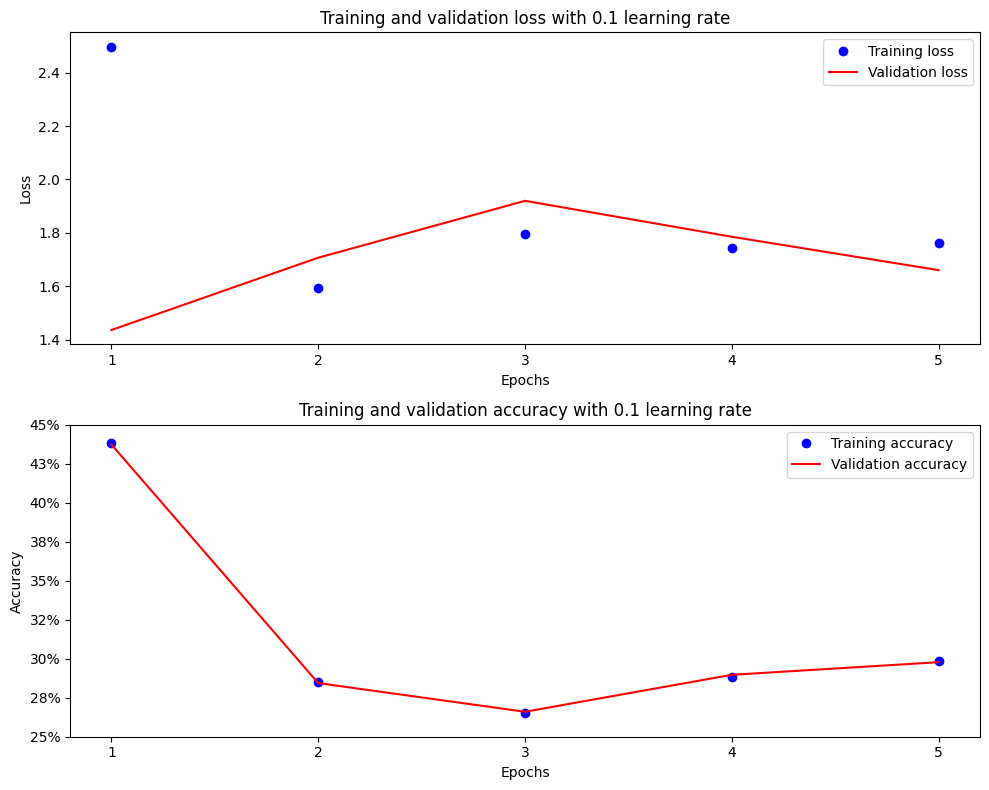

In [47]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from torchvision import datasets
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Bật chế độ vẽ đồ thị hiển thị trực quan ngay dưới ô code
%matplotlib inline

device = 'cuda' if torch.cuda.is_available() else 'cpu'
data_folder = './data/FMNIST'

# --- 1. TẢI DỮ LIỆU ĐẦU VÀO ---
fmnist = datasets.FashionMNIST(data_folder, download=True, train=True)
tr_images = fmnist.data
tr_targets = fmnist.targets

val_fmnist = datasets.FashionMNIST(data_folder, download=True, train=False)
val_images = val_fmnist.data
val_targets = val_fmnist.targets

# --- 2. LỚP DATASET VÀ QUẢN LÝ DỮ LIỆU ---
class FMNISTDataset(Dataset):
    def __init__(self, x, y):
        x = x.float() / 255
        x = x.view(-1, 28 * 28)
        self.x, self.y = x, y
    def __getitem__(self, ix):
        return self.x[ix].to(device), self.y[ix].to(device)
    def __len__(self):
        return len(self.x)

def get_data():
    train = FMNISTDataset(tr_images, tr_targets)
    trn_dl = DataLoader(train, batch_size=32, shuffle=True)
    val = FMNISTDataset(val_images, val_targets)
    val_dl = DataLoader(val, batch_size=len(val_images), shuffle=False)
    return trn_dl, val_dl

# --- 3. KHỞI TẠO MÔ HÌNH VỚI LEARNING RATE = 0.1 (Trang 34) ---
def get_model():
    model = nn.Sequential(
        nn.Linear(28 * 28, 1000),
        nn.ReLU(),
        nn.Linear(1000, 10)
    ).to(device)

    loss_fn = nn.CrossEntropyLoss()
    # Thiết lập tốc độ học cực lớn lr=1e-1 (0.1) bằng bộ tối ưu Adam theo tài liệu
    optimizer = Adam(model.parameters(), lr=1e-1)
    return model, loss_fn, optimizer

# SỬA LỖI: Đồng bộ tham số 'opt' thay cho 'optimizer' cục bộ
def train_batch(x, y, model, opt, loss_fn):
    model.train()
    prediction = model(x)
    batch_loss = loss_fn(prediction, y)
    batch_loss.backward()
    opt.step()
    opt.zero_grad()
    return batch_loss.item()

def accuracy(x, y, model):
    model.eval()
    with torch.no_grad():
        prediction = model(x)
    max_values, argmaxes = prediction.max(-1)
    is_correct = argmaxes == y
    return is_correct.cpu().numpy().tolist()

@torch.no_grad()
def val_loss(x, y, model, loss_fn):
    model.eval()
    prediction = model(x)
    val_loss_val = loss_fn(prediction, y)
    return val_loss_val.item()

# --- 4. TIẾN HÀNH CHẠY THÍ NGHIỆM (5 EPOCHS) ---
trn_dl, val_dl = get_data()
model, loss_fn, optimizer = get_model()

train_losses, train_accuracies = [], []
val_losses, val_accuracies = [], []

for epoch in range(5):
    train_epoch_losses, train_epoch_accuracies = [], []

    for ix, batch in enumerate(iter(trn_dl)):
        x, y = batch
        batch_loss = train_batch(x, y, model, optimizer, loss_fn)
        train_epoch_losses.append(batch_loss)
    train_epoch_loss = np.array(train_epoch_losses).mean()

    for ix, batch in enumerate(iter(trn_dl)):
        x, y = batch
        is_correct = accuracy(x, y, model)
        train_epoch_accuracies.extend(is_correct)
    train_epoch_accuracy = np.mean(train_epoch_accuracies)

    for ix, batch in enumerate(iter(val_dl)):
        x, y = batch
        val_is_correct = accuracy(x, y, model)
        # ĐÃ SỬA: Thêm đối số loss_fn và căn chỉnh lại thụt lề chuẩn xác
        validation_loss = val_loss(x, y, model, loss_fn)
    val_epoch_accuracy = np.mean(val_is_correct)

    train_losses.append(train_epoch_loss)
    train_accuracies.append(train_epoch_accuracy)
    val_losses.append(validation_loss)
    val_accuracies.append(val_epoch_accuracy)
    print(f"Epoch {epoch} -> Train Loss: {train_epoch_loss:.4f} | Train Acc: {train_epoch_accuracy*100:.2f}%")

# --- 5. VẼ ĐỒ THỊ ĐÔI HÀNG DỌC (Trang 35) ---
epochs = np.arange(5) + 1
plt.figure(figsize=(10, 8))

# Đồ thị phía trên: Loss
plt.subplot(211)
plt.plot(epochs, train_losses, 'bo', label='Training loss')
plt.plot(epochs, val_losses, 'r', label='Validation loss')
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.title('Training and validation loss with 0.1 learning rate')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(False)

# Đồ thị phía dưới: Accuracy
plt.subplot(212)
plt.plot(epochs, train_accuracies, 'bo', label='Training accuracy')
plt.plot(epochs, val_accuracies, 'r', label='Validation accuracy')
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.title('Training and validation accuracy with 0.1 learning rate')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

# Chuẩn hóa nhãn trục Y phần trăm (%)
ticks_loc = plt.gca().get_yticks()
plt.gca().set_yticks(ticks_loc)
plt.gca().set_yticklabels(['{:.0f}%'.format(x*100) for x in ticks_loc])

plt.legend()
plt.grid(False)

plt.tight_layout()
plt.show() # Chỉ gọi duy nhất một lần ở cuối

Epoch 0 -> Train Loss: 0.4714 | Val Acc: 83.40%
Epoch 1 -> Train Loss: 0.3563 | Val Acc: 86.89%
Epoch 2 -> Train Loss: 0.3186 | Val Acc: 86.37%
Epoch 3 -> Train Loss: 0.2992 | Val Acc: 87.03%
Epoch 4 -> Train Loss: 0.2769 | Val Acc: 87.98%


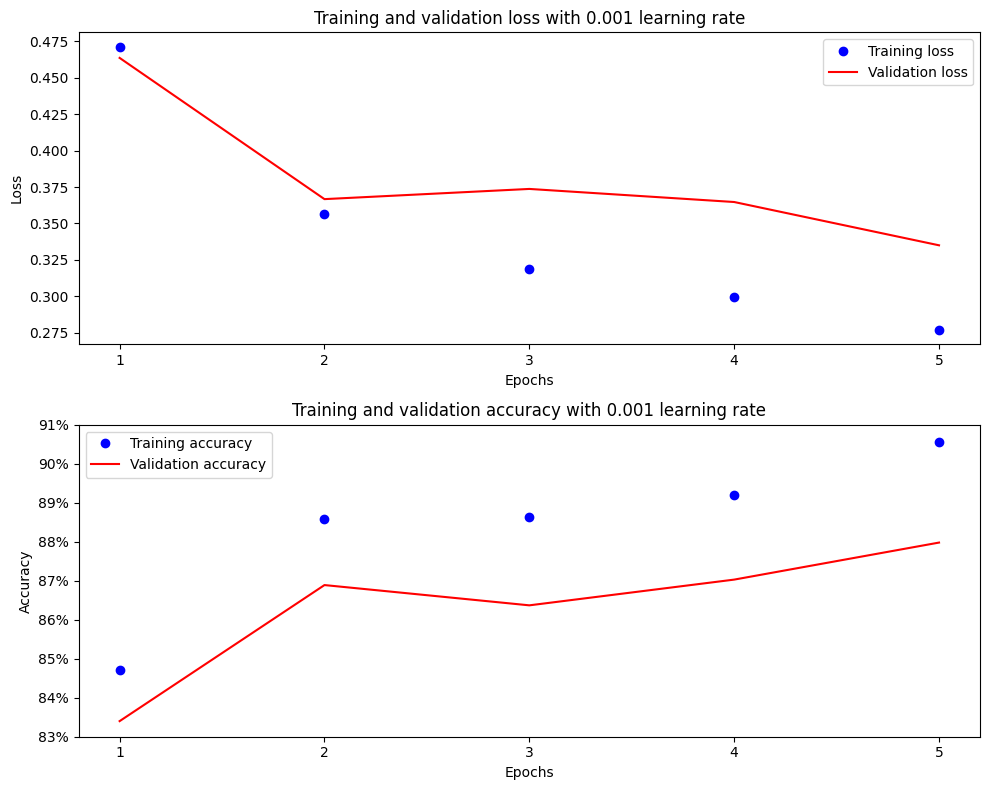

In [48]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from torchvision import datasets
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Bật chế độ vẽ đồ thị hiển thị trực quan ngay dưới ô code
%matplotlib inline

device = 'cuda' if torch.cuda.is_available() else 'cpu'
data_folder = './data/FMNIST'

# --- 1. TẢI DỮ LIỆU ĐẦU VÀO ---
fmnist = datasets.FashionMNIST(data_folder, download=True, train=True)
tr_images = fmnist.data
tr_targets = fmnist.targets

val_fmnist = datasets.FashionMNIST(data_folder, download=True, train=False)
val_images = val_fmnist.data
val_targets = val_fmnist.targets

# --- 2. LỚP DATASET VÀ QUẢN LÝ DỮ LIỆU ---
class FMNISTDataset(Dataset):
    def __init__(self, x, y):
        x = x.float() / 255
        x = x.view(-1, 28 * 28)
        self.x, self.y = x, y
    def __getitem__(self, ix):
        return self.x[ix].to(device), self.y[ix].to(device)
    def __len__(self):
        return len(self.x)

def get_data():
    train = FMNISTDataset(tr_images, tr_targets)
    trn_dl = DataLoader(train, batch_size=32, shuffle=True)
    val = FMNISTDataset(val_images, val_targets)
    val_dl = DataLoader(val, batch_size=len(val_images), shuffle=False)
    return trn_dl, val_dl

# --- 3. KHỞI TẠO MÔ HÌNH VỚI LEARNING RATE TỐI ƯU = 0.001 (Trang 35) ---
def get_model():
    model = nn.Sequential(
        nn.Linear(28 * 28, 1000),
        nn.ReLU(),
        nn.Linear(1000, 10)
    ).to(device)

    loss_fn = nn.CrossEntropyLoss()
    # Cấu hình tốc độ học chuẩn lr=1e-3 (0.001) bằng Adam theo tài liệu
    optimizer = Adam(model.parameters(), lr=1e-3)
    return model, loss_fn, optimizer

# SỬA LỖI: Đồng bộ sử dụng tham số 'opt' truyền vào
def train_batch(x, y, model, opt, loss_fn):
    model.train()
    prediction = model(x)
    batch_loss = loss_fn(prediction, y)
    batch_loss.backward()
    opt.step()
    opt.zero_grad()
    return batch_loss.item()

def accuracy(x, y, model):
    model.eval()
    with torch.no_grad():
        prediction = model(x)
    max_values, argmaxes = prediction.max(-1)
    is_correct = argmaxes == y
    return is_correct.cpu().numpy().tolist()

@torch.no_grad()
def val_loss(x, y, model, loss_fn):
    model.eval()
    prediction = model(x)
    val_loss_val = loss_fn(prediction, y)
    return val_loss_val.item()

# --- 4. TIẾN HÀNH CHẠY THÍ NGHIỆM (5 EPOCHS) ---
trn_dl, val_dl = get_data()
model, loss_fn, optimizer = get_model()

train_losses, train_accuracies = [], []
val_losses, val_accuracies = [], []

for epoch in range(5):
    train_epoch_losses, train_epoch_accuracies = [], []

    for ix, batch in enumerate(iter(trn_dl)):
        x, y = batch
        batch_loss = train_batch(x, y, model, optimizer, loss_fn)
        train_epoch_losses.append(batch_loss)
    train_epoch_loss = np.array(train_epoch_losses).mean()

    for ix, batch in enumerate(iter(trn_dl)):
        x, y = batch
        is_correct = accuracy(x, y, model)
        train_epoch_accuracies.extend(is_correct)
    train_epoch_accuracy = np.mean(train_epoch_accuracies)

    for ix, batch in enumerate(iter(val_dl)):
        x, y = batch
        val_is_correct = accuracy(x, y, model)
        # ĐÃ SỬA: Thêm đối số loss_fn và chuẩn hóa lề dòng thụt vào
        validation_loss = val_loss(x, y, model, loss_fn)
    val_epoch_accuracy = np.mean(val_is_correct)

    train_losses.append(train_epoch_loss)
    train_accuracies.append(train_epoch_accuracy)
    val_losses.append(validation_loss)
    val_accuracies.append(val_epoch_accuracy)
    print(f"Epoch {epoch} -> Train Loss: {train_epoch_loss:.4f} | Val Acc: {val_epoch_accuracy*100:.2f}%")

# --- 5. VẼ ĐỒ THỊ ĐÔI HÀNG DỌC CHUẨN (Trang 36) ---
epochs = np.arange(5) + 1
plt.figure(figsize=(10, 8))

# Đồ thị 1: Loss
plt.subplot(211)
plt.plot(epochs, train_losses, 'bo', label='Training loss')
plt.plot(epochs, val_losses, 'r', label='Validation loss')
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.title('Training and validation loss with 0.001 learning rate')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(False)

# Đồ thị 2: Accuracy
plt.subplot(212)
plt.plot(epochs, train_accuracies, 'bo', label='Training accuracy')
plt.plot(epochs, val_accuracies, 'r', label='Validation accuracy')
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.title('Training and validation accuracy with 0.001 learning rate')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

# Định dạng hiển thị nhãn trục Y phần trăm (%)
ticks_loc = plt.gca().get_yticks()
plt.gca().set_yticks(ticks_loc)
plt.gca().set_yticklabels(['{:.0f}%'.format(x*100) for x in ticks_loc])

plt.legend()
plt.grid(False)

plt.tight_layout()
plt.show() # SỬA LỖI: Chỉ gọi duy nhất 1 lần ở cuối cùng để xuất biểu đồ kép hàng dọc

Epoch 0 -> Train Loss: 1.1801 | Val Acc: 73.66%
Epoch 1 -> Train Loss: 0.6896 | Val Acc: 78.48%
Epoch 2 -> Train Loss: 0.5911 | Val Acc: 80.10%
Epoch 3 -> Train Loss: 0.5413 | Val Acc: 81.48%
Epoch 4 -> Train Loss: 0.5101 | Val Acc: 82.00%


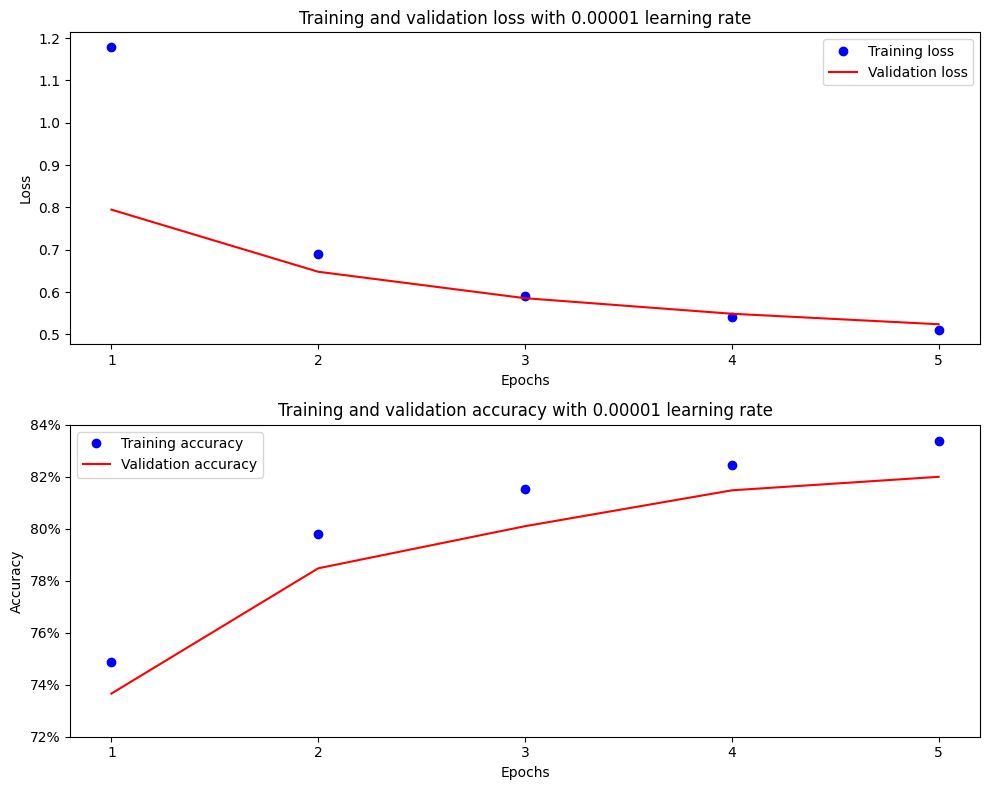

In [49]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from torchvision import datasets
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Bật chế độ vẽ đồ thị hiển thị trực quan ngay dưới ô code
%matplotlib inline

device = 'cuda' if torch.cuda.is_available() else 'cpu'
data_folder = './data/FMNIST'

# --- 1. TẢI DỮ LIỆU ĐẦU VÀO ---
fmnist = datasets.FashionMNIST(data_folder, download=True, train=True)
tr_images = fmnist.data
tr_targets = fmnist.targets

val_fmnist = datasets.FashionMNIST(data_folder, download=True, train=False)
val_images = val_fmnist.data
val_targets = val_fmnist.targets

# --- 2. LỚP DATASET VÀ QUẢN LÝ DỮ LIỆU ---
class FMNISTDataset(Dataset):
    def __init__(self, x, y):
        x = x.float() / 255
        x = x.view(-1, 28 * 28)
        self.x, self.y = x, y
    def __getitem__(self, ix):
        return self.x[ix].to(device), self.y[ix].to(device)
    def __len__(self):
        return len(self.x)

def get_data():
    train = FMNISTDataset(tr_images, tr_targets)
    trn_dl = DataLoader(train, batch_size=32, shuffle=True)
    val = FMNISTDataset(val_images, val_targets)
    val_dl = DataLoader(val, batch_size=len(val_images), shuffle=False)
    return trn_dl, val_dl

# --- 3. KHỞI TẠO MÔ HÌNH VỚI LEARNING RATE CỰC THẤP = 0.00001 (Trang 36) ---
def get_model():
    model = nn.Sequential(
        nn.Linear(28 * 28, 1000),
        nn.ReLU(),
        nn.Linear(1000, 10)
    ).to(device)

    loss_fn = nn.CrossEntropyLoss()
    # Thiết lập tốc độ học cực nhỏ lr=1e-5 (0.00001) bằng Adam theo tài liệu
    optimizer = Adam(model.parameters(), lr=1e-5)
    return model, loss_fn, optimizer

def train_batch(x, y, model, opt, loss_fn):
    model.train()
    prediction = model(x)
    batch_loss = loss_fn(prediction, y)
    batch_loss.backward()
    opt.step()
    opt.zero_grad()
    return batch_loss.item()

def accuracy(x, y, model):
    model.eval()
    with torch.no_grad():
        prediction = model(x)
    max_values, argmaxes = prediction.max(-1)
    is_correct = argmaxes == y
    return is_correct.cpu().numpy().tolist()

@torch.no_grad()
def val_loss(x, y, model, loss_fn):
    model.eval()
    prediction = model(x)
    val_loss_val = loss_fn(prediction, y)
    return val_loss_val.item()

# --- 4. TIẾN HÀNH CHẠY THÍ NGHIỆM (5 EPOCHS) ---
trn_dl, val_dl = get_data()
model, loss_fn, optimizer = get_model()

train_losses, train_accuracies = [], []
val_losses, val_accuracies = [], []

for epoch in range(5):
    train_epoch_losses, train_epoch_accuracies = [], []

    for ix, batch in enumerate(iter(trn_dl)):
        x, y = batch
        batch_loss = train_batch(x, y, model, optimizer, loss_fn)
        train_epoch_losses.append(batch_loss)
    train_epoch_loss = np.array(train_epoch_losses).mean()

    for ix, batch in enumerate(iter(trn_dl)):
        x, y = batch
        is_correct = accuracy(x, y, model)
        train_epoch_accuracies.extend(is_correct)
    train_epoch_accuracy = np.mean(train_epoch_accuracies)

    for ix, batch in enumerate(iter(val_dl)):
        x, y = batch
        val_is_correct = accuracy(x, y, model)
        # ĐÃ SỬA: Thêm đối số loss_fn và chuẩn hóa lề dòng thụt vào
        validation_loss = val_loss(x, y, model, loss_fn)
    val_epoch_accuracy = np.mean(val_is_correct)

    train_losses.append(train_epoch_loss)
    train_accuracies.append(train_epoch_accuracy)
    val_losses.append(validation_loss)
    val_accuracies.append(val_epoch_accuracy)
    print(f"Epoch {epoch} -> Train Loss: {train_epoch_loss:.4f} | Val Acc: {val_epoch_accuracy*100:.2f}%")

# --- 5. VẼ ĐỒ THỊ ĐÔI HÀNG DỌC CHUẨN (Trang 36) ---
epochs = np.arange(5) + 1
plt.figure(figsize=(10, 8))

# Đồ thị 1: Loss
plt.subplot(211)
plt.plot(epochs, train_losses, 'bo', label='Training loss')
plt.plot(epochs, val_losses, 'r', label='Validation loss')
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.title('Training and validation loss with 0.00001 learning rate')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(False)

# Đồ thị 2: Accuracy
plt.subplot(212)
plt.plot(epochs, train_accuracies, 'bo', label='Training accuracy')
plt.plot(epochs, val_accuracies, 'r', label='Validation accuracy')
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.title('Training and validation accuracy with 0.00001 learning rate')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

# Định dạng hiển thị nhãn trục Y phần trăm (%)
ticks_loc = plt.gca().get_yticks()
plt.gca().set_yticks(ticks_loc)
plt.gca().set_yticklabels(['{:.0f}%'.format(x*100) for x in ticks_loc])

plt.legend()
plt.grid(False)

plt.tight_layout()
plt.show() # SỬA LỖI: Chỉ gọi duy nhất 1 lần ở cuối cùng để xuất biểu đồ kép hàng dọc

Epoch 0 -> Train Loss: 3.0133 | Val Acc: 24.65%
Epoch 1 -> Train Loss: 2.1868 | Val Acc: 21.45%
Epoch 2 -> Train Loss: 2.1747 | Val Acc: 22.69%
Epoch 3 -> Train Loss: 2.0821 | Val Acc: 20.94%
Epoch 4 -> Train Loss: 2.1084 | Val Acc: 20.12%


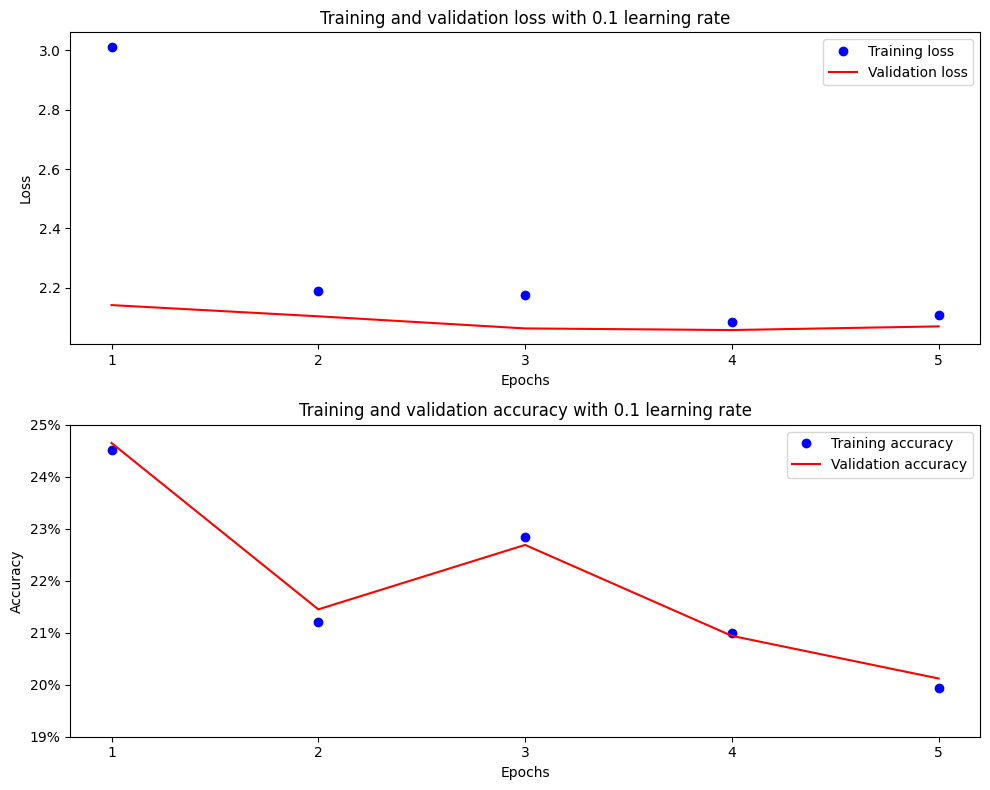

In [50]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from torchvision import datasets
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Bật chế độ vẽ đồ thị hiển thị trực quan ngay dưới ô code
%matplotlib inline

device = 'cuda' if torch.cuda.is_available() else 'cpu'
data_folder = './data/FMNIST'

# --- 1. TẢI DỮ LIỆU ĐẦU VÀO ---
fmnist = datasets.FashionMNIST(data_folder, download=True, train=True)
tr_images = fmnist.data
tr_targets = fmnist.targets

val_fmnist = datasets.FashionMNIST(data_folder, download=True, train=False)
val_images = val_fmnist.data
val_targets = val_fmnist.targets

# --- 2. LỚP DATASET CÓ CHUẨN HÓA DỮ LIỆU ---
class FMNISTDataset(Dataset):
    def __init__(self, x, y):
        # Khôi phục chia 255 để tránh hiện tượng tràn bộ nhớ số thực khi lr lớn
        x = x.float() / 255
        x = x.view(-1, 28 * 28)
        self.x, self.y = x, y
    def __getitem__(self, ix):
        return self.x[ix].to(device), self.y[ix].to(device)
    def __len__(self):
        return len(self.x)

def get_data():
    train = FMNISTDataset(tr_images, tr_targets)
    trn_dl = DataLoader(train, batch_size=32, shuffle=True)
    val = FMNISTDataset(val_images, val_targets)
    val_dl = DataLoader(val, batch_size=len(val_images), shuffle=False)
    return trn_dl, val_dl

# --- 3. KHỞI TẠO MÔ HÌNH VỚI LEARNING RATE LỚN = 0.1 ---
def get_model():
    model = nn.Sequential(
        nn.Linear(28 * 28, 1000),
        nn.ReLU(),
        nn.Linear(1000, 10)
    ).to(device)

    loss_fn = nn.CrossEntropyLoss()
    # Thiết lập cấu hình tốc độ học lr=1e-1 (0.1) theo tài liệu
    optimizer = Adam(model.parameters(), lr=1e-1)
    return model, loss_fn, optimizer

# SỬA LỖI: Đồng bộ sử dụng tham số đại diện 'opt' truyền vào
def train_batch(x, y, model, opt, loss_fn):
    model.train()
    prediction = model(x)
    batch_loss = loss_fn(prediction, y)
    batch_loss.backward()
    opt.step()
    opt.zero_grad()
    return batch_loss.item()

# SỬA LỖI 1: Đưa hàm accuracy tách biệt ra ngoài (Hủy thụt lề lồng nhau)
def accuracy(x, y, model):
    model.eval()
    with torch.no_grad():
        prediction = model(x)
    max_values, argmaxes = prediction.max(-1)
    is_correct = argmaxes == y
    return is_correct.cpu().numpy().tolist()

@torch.no_grad()
def val_loss(x, y, model, loss_fn):
    model.eval()
    prediction = model(x)
    val_loss_val = loss_fn(prediction, y)
    return val_loss_val.item()

# --- 4. TIẾN HÀNH CHẠY THÍ NGHIỆM (5 EPOCHS) ---
trn_dl, val_dl = get_data()
model, loss_fn, optimizer = get_model()

train_losses, train_accuracies = [], []
val_losses, val_accuracies = [], []

for epoch in range(5):
    train_epoch_losses, train_epoch_accuracies = [], []

    for ix, batch in enumerate(iter(trn_dl)):
        x, y = batch
        batch_loss = train_batch(x, y, model, optimizer, loss_fn)
        train_epoch_losses.append(batch_loss)
    train_epoch_loss = np.array(train_epoch_losses).mean()

    for ix, batch in enumerate(iter(trn_dl)):
        x, y = batch
        is_correct = accuracy(x, y, model)
        train_epoch_accuracies.extend(is_correct)
    train_epoch_accuracy = np.mean(train_epoch_accuracies)

    # SỬA LỖI 3: Chuẩn hóa lại toàn bộ lề dòng (Indentation) của cụm lệnh dưới đây
    for ix, batch in enumerate(iter(val_dl)):
        x, y = batch
        val_is_correct = accuracy(x, y, model)
        validation_loss = val_loss(x, y, model, loss_fn)
    val_epoch_accuracy = np.mean(val_is_correct)

    train_losses.append(train_epoch_loss)
    train_accuracies.append(train_epoch_accuracy)
    val_losses.append(validation_loss)
    val_accuracies.append(val_epoch_accuracy)
    print(f"Epoch {epoch} -> Train Loss: {train_epoch_loss:.4f} | Val Acc: {val_epoch_accuracy*100:.2f}%")

# --- 5. V VẼ BIỂU ĐỒ ĐÔI HÀNG DỌC CHUẨN ---
epochs = np.arange(5) + 1
plt.figure(figsize=(10, 8))

# Đồ thị trên: Loss
plt.subplot(211)
plt.plot(epochs, train_losses, 'bo', label='Training loss')
plt.plot(epochs, val_losses, 'r', label='Validation loss')
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.title('Training and validation loss with 0.1 learning rate')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(False)

# Đồ thị dưới: Accuracy
plt.subplot(212)
plt.plot(epochs, train_accuracies, 'bo', label='Training accuracy')
plt.plot(epochs, val_accuracies, 'r', label='Validation accuracy')
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.title('Training and validation accuracy with 0.1 learning rate')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

# Định dạng hiển thị nhãn trục Y phần trăm (%)
ticks_loc = plt.gca().get_yticks()
plt.gca().set_yticks(ticks_loc)
plt.gca().set_yticklabels(['{:.0f}%'.format(x*100) for x in ticks_loc])

plt.legend()
plt.grid(False)

plt.tight_layout()
plt.show()

Epoch 0 -> Train Loss: 0.4770 | Val Acc: 84.09%
Epoch 1 -> Train Loss: 0.3612 | Val Acc: 87.15%
Epoch 2 -> Train Loss: 0.3210 | Val Acc: 87.17%
Epoch 3 -> Train Loss: 0.2965 | Val Acc: 86.15%
Epoch 4 -> Train Loss: 0.2807 | Val Acc: 87.73%


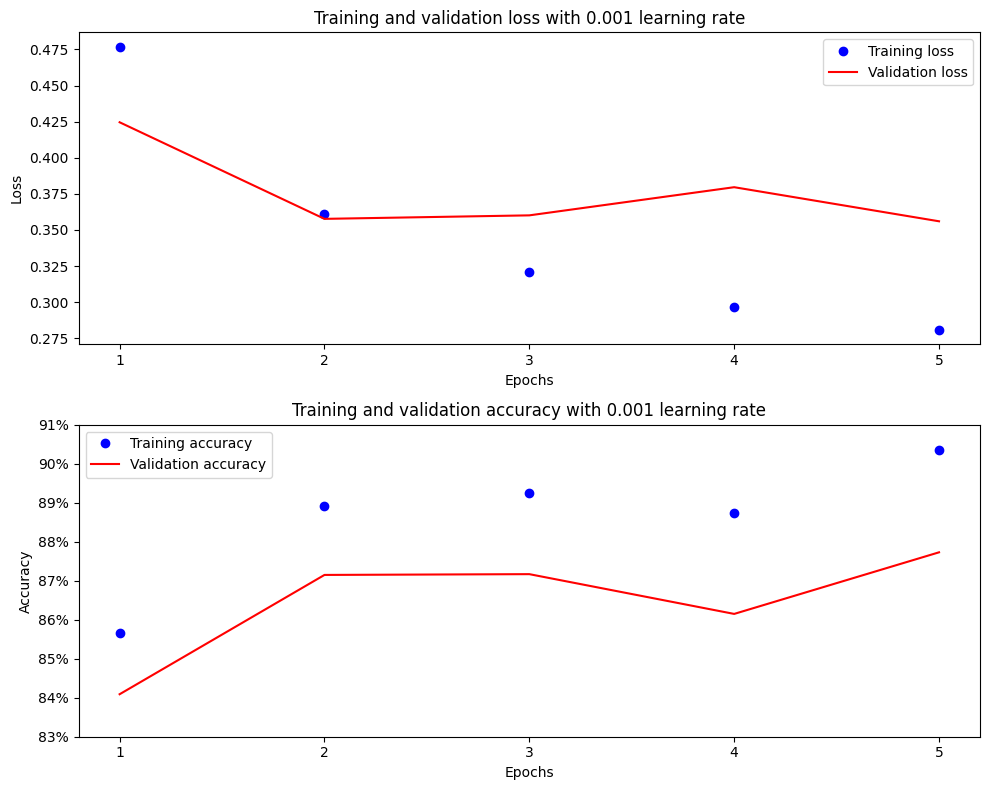

In [51]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from torchvision import datasets
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Bật chế độ vẽ đồ thị hiển thị trực quan ngay dưới ô code
%matplotlib inline

device = 'cuda' if torch.cuda.is_available() else 'cpu'
data_folder = './data/FMNIST'

# --- 1. TẢI DỮ LIỆU ĐẦU VÀO ---
fmnist = datasets.FashionMNIST(data_folder, download=True, train=True)
tr_images = fmnist.data
tr_targets = fmnist.targets

val_fmnist = datasets.FashionMNIST(data_folder, download=True, train=False)
val_images = val_fmnist.data
val_targets = val_fmnist.targets

# --- 2. LỚP DATASET VÀ QUẢN LÝ DỮ LIỆU ---
class FMNISTDataset(Dataset):
    def __init__(self, x, y):
        x = x.float() / 255
        x = x.view(-1, 28 * 28)
        self.x, self.y = x, y
    def __getitem__(self, ix):
        return self.x[ix].to(device), self.y[ix].to(device)
    def __len__(self):
        return len(self.x)

def get_data():
    train = FMNISTDataset(tr_images, tr_targets)
    trn_dl = DataLoader(train, batch_size=32, shuffle=True)
    val = FMNISTDataset(val_images, val_targets)
    val_dl = DataLoader(val, batch_size=len(val_images), shuffle=False)
    return trn_dl, val_dl

# --- 3. KHỞI TẠO MÔ HÌNH VỚI LEARNING RATE TỐI ƯU = 0.001 ---
def get_model():
    model = nn.Sequential(
        nn.Linear(28 * 28, 1000),
        nn.ReLU(),
        nn.Linear(1000, 10)
    ).to(device)

    loss_fn = nn.CrossEntropyLoss()
    optimizer = Adam(model.parameters(), lr=1e-3)
    return model, loss_fn, optimizer

def train_batch(x, y, model, opt, loss_fn):
    model.train()
    prediction = model(x)
    batch_loss = loss_fn(prediction, y)
    batch_loss.backward()
    opt.step()
    opt.zero_grad()
    return batch_loss.item()

def accuracy(x, y, model):
    model.eval()
    with torch.no_grad():
        prediction = model(x)
    max_values, argmaxes = prediction.max(-1)
    is_correct = argmaxes == y
    return is_correct.cpu().numpy().tolist()

@torch.no_grad()
def val_loss(x, y, model, loss_fn):
    model.eval()
    prediction = model(x)
    val_loss_val = loss_fn(prediction, y)
    return val_loss_val.item()

# --- 4. TIẾN HÀNH CHẠY THÍ NGHIỆM (5 EPOCHS) ---
trn_dl, val_dl = get_data()
model, loss_fn, optimizer = get_model()

train_losses, train_accuracies = [], []
val_losses, val_accuracies = [], []

for epoch in range(5):
    train_epoch_losses, train_epoch_accuracies = [], []

    for ix, batch in enumerate(iter(trn_dl)):
        x, y = batch
        batch_loss = train_batch(x, y, model, optimizer, loss_fn)
        train_epoch_losses.append(batch_loss)
    train_epoch_loss = np.array(train_epoch_losses).mean()

    for ix, batch in enumerate(iter(trn_dl)):
        x, y = batch
        is_correct = accuracy(x, y, model)
        train_epoch_accuracies.extend(is_correct)
    train_epoch_accuracy = np.mean(train_epoch_accuracies)

    for ix, batch in enumerate(iter(val_dl)):
        x, y = batch
        val_is_correct = accuracy(x, y, model)
        validation_loss = val_loss(x, y, model, loss_fn)
    val_epoch_accuracy = np.mean(val_is_correct)

    # --- PHẦN CODE BỔ SUNG ĐOẠN ĐUÔI BỊ THIẾU ---
    train_losses.append(train_epoch_loss)
    train_accuracies.append(train_epoch_accuracy)
    val_losses.append(validation_loss)
    val_accuracies.append(val_epoch_accuracy)
    print(f"Epoch {epoch} -> Train Loss: {train_epoch_loss:.4f} | Val Acc: {val_epoch_accuracy*100:.2f}%")

# --- 5. ĐOẠN VẼ BIỂU ĐỒ ĐÔI HÀNG DỌC CHUẨN TÀI LIỆU ---
epochs = np.arange(5) + 1
plt.figure(figsize=(10, 8))

# Đồ thị phía trên: Biểu diễn sai số Loss
plt.subplot(211)
plt.plot(epochs, train_losses, 'bo', label='Training loss')
plt.plot(epochs, val_losses, 'r', label='Validation loss')
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.title('Training and validation loss with 0.001 learning rate')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(False)

# Đồ thị phía dưới: Biểu diễn độ chính xác Accuracy
plt.subplot(212)
plt.plot(epochs, train_accuracies, 'bo', label='Training accuracy')
plt.plot(epochs, val_accuracies, 'r', label='Validation accuracy')
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.title('Training and validation accuracy with 0.001 learning rate')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

# Định dạng hiển thị nhãn phần trăm (%) cho trục Y
ticks_loc = plt.gca().get_yticks()
plt.gca().set_yticks(ticks_loc)
plt.gca().set_yticklabels(['{:.0f}%'.format(x*100) for x in ticks_loc])

plt.legend()
plt.grid(False)

plt.tight_layout()
plt.show()

Epoch 0 -> Train Loss: 1.1861 | Val Acc: 73.68%
Epoch 1 -> Train Loss: 0.6882 | Val Acc: 78.52%
Epoch 2 -> Train Loss: 0.5910 | Val Acc: 79.75%
Epoch 3 -> Train Loss: 0.5417 | Val Acc: 81.46%
Epoch 4 -> Train Loss: 0.5104 | Val Acc: 82.15%


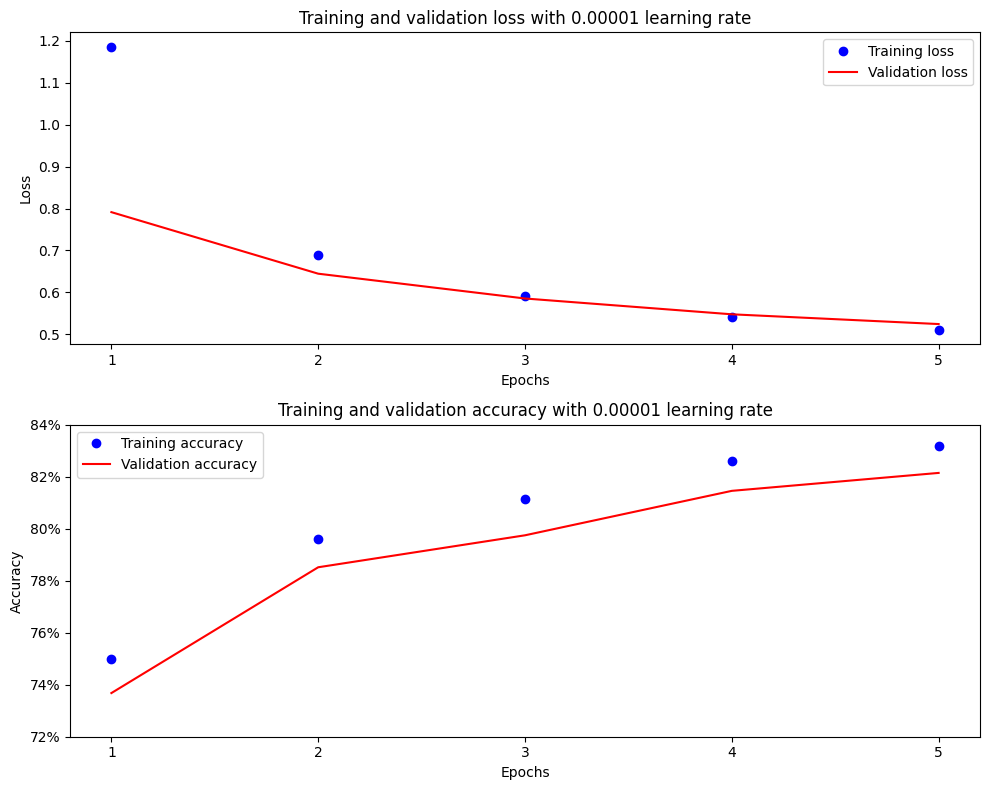

In [52]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from torchvision import datasets
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Bật chế độ vẽ đồ thị hiển thị trực quan ngay dưới ô code
%matplotlib inline

device = 'cuda' if torch.cuda.is_available() else 'cpu'
data_folder = './data/FMNIST'

# --- 1. TẢI DỮ LIỆU ĐẦU VÀO ---
fmnist = datasets.FashionMNIST(data_folder, download=True, train=True)
tr_images = fmnist.data
tr_targets = fmnist.targets

val_fmnist = datasets.FashionMNIST(data_folder, download=True, train=False)
val_images = val_fmnist.data
val_targets = val_fmnist.targets

# --- 2. LỚP DATASET VÀ QUẢN LÝ DỮ LIỆU ---
class FMNISTDataset(Dataset):
    def __init__(self, x, y):
        x = x.float() / 255
        x = x.view(-1, 28 * 28)
        self.x, self.y = x, y
    def __getitem__(self, ix):
        return self.x[ix].to(device), self.y[ix].to(device)
    def __len__(self):
        return len(self.x)

def get_data():
    train = FMNISTDataset(tr_images, tr_targets)
    trn_dl = DataLoader(train, batch_size=32, shuffle=True)
    val = FMNISTDataset(val_images, val_targets)
    val_dl = DataLoader(val, batch_size=len(val_images), shuffle=False)
    return trn_dl, val_dl

# --- 3. KHỞI TẠO MÔ HÌNH VỚI LEARNING RATE THẤP = 1e-5 (Trang 36) ---
def get_model():
    model = nn.Sequential(
        nn.Linear(28 * 28, 1000),
        nn.ReLU(),
        nn.Linear(1000, 10)
    ).to(device)

    loss_fn = nn.CrossEntropyLoss()
    optimizer = Adam(model.parameters(), lr=1e-5)
    return model, loss_fn, optimizer

def train_batch(x, y, model, opt, loss_fn):
    model.train()
    prediction = model(x)
    batch_loss = loss_fn(prediction, y)
    batch_loss.backward()
    opt.step()
    opt.zero_grad()
    return batch_loss.item()

def accuracy(x, y, model):
    model.eval()
    with torch.no_grad():
        prediction = model(x)
    max_values, argmaxes = prediction.max(-1)
    is_correct = argmaxes == y
    return is_correct.cpu().numpy().tolist()

@torch.no_grad()
def val_loss(x, y, model, loss_fn):
    model.eval()
    prediction = model(x)
    val_loss_val = loss_fn(prediction, y)
    return val_loss_val.item()

# --- 4. TIẾN HÀNH CHẠY THÍ NGHIỆM (5 EPOCHS) ---
trn_dl, val_dl = get_data()
model, loss_fn, optimizer = get_model()

train_losses, train_accuracies = [], []
val_losses, val_accuracies = [], []

for epoch in range(5):
    train_epoch_losses, train_epoch_accuracies = [], []

    # ĐÃ SỬA: Căn thẳng lề vòng lặp huấn luyện chính xác
    for ix, batch in enumerate(iter(trn_dl)):
        x, y = batch
        batch_loss = train_batch(x, y, model, optimizer, loss_fn)
        train_epoch_losses.append(batch_loss)
    train_epoch_loss = np.array(train_epoch_losses).mean()

    for ix, batch in enumerate(iter(trn_dl)):
        x, y = batch
        is_correct = accuracy(x, y, model)
        train_epoch_accuracies.extend(is_correct)
    train_epoch_accuracy = np.mean(train_epoch_accuracies)

    for ix, batch in enumerate(iter(val_dl)):
        x, y = batch
        val_is_correct = accuracy(x, y, model)
        # ĐÃ SỬA: Bổ sung loss_fn vào làm đối số thứ tư
        validation_loss = val_loss(x, y, model, loss_fn)
    val_epoch_accuracy = np.mean(val_is_correct)

    train_losses.append(train_epoch_loss)
    train_accuracies.append(train_epoch_accuracy)
    val_losses.append(validation_loss)
    val_accuracies.append(val_epoch_accuracy)
    print(f"Epoch {epoch} -> Train Loss: {train_epoch_loss:.4f} | Val Acc: {val_epoch_accuracy*100:.2f}%")

# --- 5. VẼ ĐỒ THỊ ĐÔI HÀNG DỌC CHUẨN (Trang 36) ---
epochs = np.arange(5) + 1
plt.figure(figsize=(10, 8))

# Đồ thị 1: Loss
plt.subplot(211)
plt.plot(epochs, train_losses, 'bo', label='Training loss')
plt.plot(epochs, val_losses, 'r', label='Validation loss')
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.title('Training and validation loss with 0.00001 learning rate')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(False)

# Đồ thị 2: Accuracy
plt.subplot(212)
plt.plot(epochs, train_accuracies, 'bo', label='Training accuracy')
plt.plot(epochs, val_accuracies, 'r', label='Validation accuracy')
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.title('Training and validation accuracy with 0.00001 learning rate')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

# Định dạng hiển thị nhãn trục Y phần trăm (%)
ticks_loc = plt.gca().get_yticks()
plt.gca().set_yticks(ticks_loc)
plt.gca().set_yticklabels(['{:.0f}%'.format(x*100) for x in ticks_loc])

# ĐÃ SỬA: Đổi lt.legend() thành plt.legend() chuẩn thư viện
plt.legend()
plt.grid(False)

plt.tight_layout()
plt.show()